<!-- Reemplaza USUARIO/REPO por tu repositorio para activar el badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/03_segmentacion_clientes_marketing.ipynb)

# Segmentación de clientes en marketing directo

**Análisis estadístico descriptivo y exploratorio de una campaña piloto**
*2.220 clientes · 37 variables · depuración validada, imputación múltiple y contrastes no paramétricos*

Luis Javier Rubio Hernández

---

Con el fin de optimizar la rentabilidad y fundamentar futuros modelos predictivos, se analiza la
base de datos de una campaña piloto de marketing directo: contacto telefónico a una muestra
aleatoria de clientes para ofrecer un nuevo dispositivo, registrando su nivel de aceptación.

Este cuaderno es la versión en Python de un análisis desarrollado originalmente en R con
`bookdown` y `mice`. Se conserva la metodología completa —incluida la prueba de Little y la
imputación múltiple por *predictive mean matching*, implementadas aquí de forma explícita— y se
añaden las verificaciones que en R quedaban implícitas en las funciones de paquete.

**Objetivo general.** Caracterizar estadísticamente los perfiles de clientes que aceptaron y
rechazaron la oferta, mediante análisis descriptivo y exploratorio.

**Objetivos específicos**

1. Cuantificar y tratar valores atípicos, inconsistencias y datos faltantes mediante técnicas
   estadísticas apropiadas.
2. Evaluar el mecanismo de generación de datos faltantes mediante pruebas estadísticas.
3. Identificar las variables demográficas, económicas y de comportamiento que diferencian a los
   clientes que aceptaron de los que rechazaron.
4. Establecer patrones y relaciones bivariadas que describan el perfil de cliente propenso a
   aceptar ofertas de marketing directo.

## 0. Configuración y carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor

AZUL, GRIS, TEXTO, GRIS_OSC, ROJO = "#0073B1", "#D4D4D4", "#333333", "#767676", "#C0392B"

mpl.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.8),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": GRIS_OSC, "axes.titlecolor": TEXTO,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "xtick.color": GRIS_OSC, "ytick.color": GRIS_OSC,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "grid.color": "#EEEEEE",
})
pd.set_option("display.width", 140)
SEMILLA = 2026

In [2]:
# Reemplaza USUARIO/REPO por tu repositorio. Si el archivo está junto al cuaderno,
# la carga local sirve de respaldo y el cuaderno corre igual.
URL = ("https://raw.githubusercontent.com/USUARIO/REPO/main/datos/"
       "campana_marketing_directo.csv")
LOCAL = "campana_marketing_directo.csv"

try:
    crudo = pd.read_csv(URL)
    print("Origen: repositorio remoto")
except Exception:
    crudo = pd.read_csv(LOCAL)
    print("Origen: copia local junto al cuaderno")
print(f"Dimensiones: {crudo.shape[0]:,} clientes x {crudo.shape[1]} variables")
crudo.head(3)

Origen: copia local junto al cuaderno
Dimensiones: 2,220 clientes x 37 variables


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,581380.0,0,0,58,635.0,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,463440.0,1,1,38,11.0,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,716130.0,0,0,26,426.0,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0


## 1. Los datos

La base documenta el perfil demográfico y el comportamiento de consumo de cada cliente: ingreso
anual, composición del hogar, antigüedad, edad, compras por canal (tienda, catálogo, web), gasto
desglosado por categoría (prefijo `Mnt`) y respuesta a cinco campañas previas. La variable
objetivo es `Response`, la respuesta a la campaña piloto.

In [3]:
continuas = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
             "MntSweetProducts", "MntGoldProds", "MntTotal", "MntRegularProds"]
discretas = ["Kidhome", "Teenhome", "Recency", "NumDealsPurchases", "NumWebPurchases",
             "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
             "Age", "Customer_Days"]
binarias = [c for c in crudo.columns if c not in continuas + discretas]

print(f"Cuantitativas continuas : {len(continuas)}")
print(f"Cuantitativas discretas : {len(discretas)}")
print(f"Cualitativas binarias   : {len(binarias)}")
print(f"\nVariable objetivo Response: "
      f"{crudo['Response'].mean():.3%} de aceptación en la campaña piloto")

Cuantitativas continuas : 9
Cuantitativas discretas : 10
Cualitativas binarias   : 18

Variable objetivo Response: 15.045% de aceptación en la campaña piloto


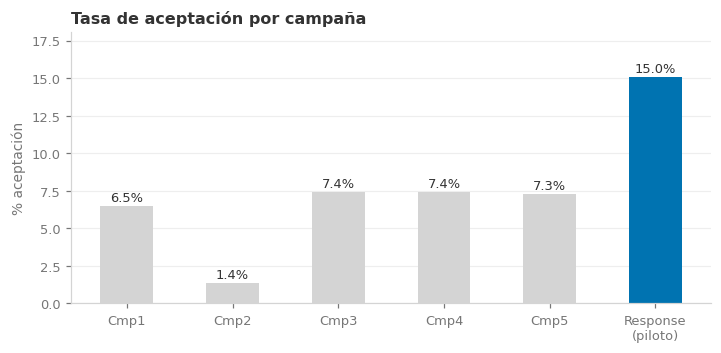

Las cinco campañas previas no superan el 7,5 %; la campaña piloto alcanza 15.0 %.


In [4]:
campanas = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4",
            "AcceptedCmp5", "Response"]
tasas = crudo[campanas].mean()*100

fig, ax = plt.subplots(figsize=(7.5, 3.2))
colores = [GRIS]*5 + [AZUL]
barras = ax.bar(["Cmp1", "Cmp2", "Cmp3", "Cmp4", "Cmp5", "Response\n(piloto)"],
                tasas.values, color=colores, width=.5)
for b, v in zip(barras, tasas.values):
    ax.text(b.get_x()+b.get_width()/2, v+.35, f"{v:.1f}%", ha="center",
            fontsize=8.5, color=TEXTO)
ax.set_ylabel("% aceptación")
ax.set_title("Tasa de aceptación por campaña")
ax.set_ylim(0, tasas.max()*1.2)
ax.grid(axis="y"); ax.set_axisbelow(True)
plt.show()

print("Las cinco campañas previas no superan el 7,5 %; la campaña piloto alcanza "
      f"{tasas['Response']:.1f} %.")

## 2. Procesamiento

### 2.1 Duplicados

Registros con información idéntica en las 37 variables. Su presencia infla artificialmente el
tamaño muestral y viola el supuesto de independencia (Barnett y Lewis, 1994).

In [5]:
n_dup = int(crudo.duplicated().sum())
sin_dup = crudo.drop_duplicates().copy()

pd.DataFrame({
    "Concepto": ["Total de datos original", "Total de duplicados",
                 "Porcentaje de duplicados", "Total sin duplicados"],
    "Valor": [f"{len(crudo):,}", f"{n_dup}", f"{100*n_dup/len(crudo):.2f} %",
              f"{len(sin_dup):,}"],
})

,Concepto,Valor
0,Total de datos original,"2,220"
1,Total de duplicados,179
2,Porcentaje de duplicados,8.06 %
3,Total sin duplicados,"2,041"


### 2.2 Estadísticos descriptivos y detección de atípicos

Se aplica el método del rango intercuartílico (Tukey, 1977):

$$\text{IQR}=Q_3-Q_1,\qquad L_{\inf}=Q_1-1{,}5\cdot\text{IQR},\qquad
L_{\sup}=Q_3+1{,}5\cdot\text{IQR}$$

In [6]:
tabla2 = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
          "MntSweetProducts", "MntGoldProds", "MntTotal", "Age", "Recency", "Customer_Days"]

desc = sin_dup[tabla2].agg(["min", "mean", "std", "median", "max"]).T
desc.insert(3, "Q1", sin_dup[tabla2].quantile(.25))
desc.insert(5, "Q3", sin_dup[tabla2].quantile(.75))
desc.columns = ["Mín", "Media", "DE", "Q1", "Mediana", "Q3", "Máx"]
desc.round(1)

,Mín,Media,DE,Q1,Mediana,Q3,Máx
Income,17300.0,516809.1,207352.5,352460.0,514120.0,681480.0,1137340.0
MntWines,0.0,301.5,332.9,24.0,174.0,499.0,1493.0
MntFruits,0.0,26.3,39.8,2.0,8.0,33.0,199.0
MntMeatProducts,0.0,166.0,219.8,16.0,68.0,230.0,1725.0
MntFishProducts,0.0,37.6,54.8,3.0,12.0,50.0,259.0
MntSweetProducts,0.0,27.3,41.6,1.0,8.0,34.0,262.0
MntGoldProds,0.0,43.9,51.7,9.0,24.0,56.0,321.0
MntTotal,4.0,564.5,577.8,55.0,343.0,965.0,2491.0
Age,25.0,51.4,13.0,43.0,50.0,61.0,240.0
Recency,0.0,48.9,28.9,24.0,49.0,74.0,99.0


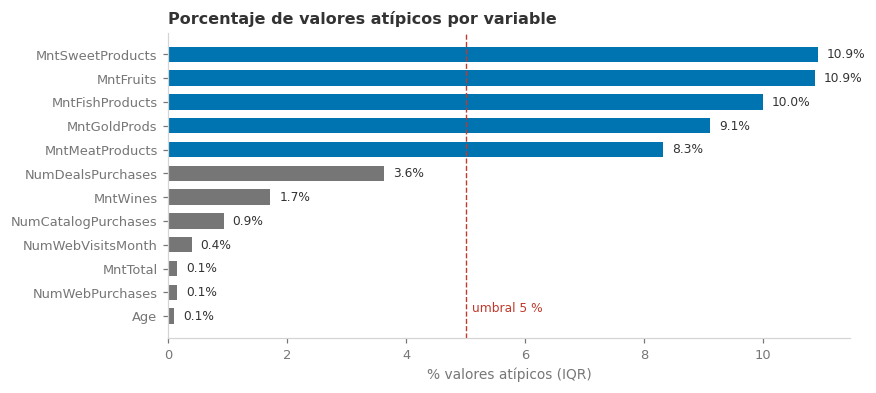

In [7]:
def pct_atipicos(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return 100*((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean()

vars_iqr = ["Age", "NumWebPurchases", "MntTotal", "NumWebVisitsMonth",
            "NumCatalogPurchases", "MntWines", "NumDealsPurchases",
            "MntMeatProducts", "MntGoldProds", "MntFishProducts",
            "MntFruits", "MntSweetProducts"]
at = pd.Series({v: pct_atipicos(sin_dup[v]) for v in vars_iqr}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
colores = [AZUL if v > 5 else GRIS_OSC for v in at.values]
ax.barh(at.index, at.values, color=colores, height=.65)
ax.axvline(5, color=ROJO, ls="--", lw=.9)
ax.text(5.1, .2, "umbral 5 %", color=ROJO, fontsize=8)
for i, v in enumerate(at.values):
    ax.text(v+.15, i, f"{v:.1f}%", va="center", fontsize=8, color=TEXTO)
ax.set_xlabel("% valores atípicos (IQR)")
ax.set_title("Porcentaje de valores atípicos por variable")
plt.show()

Las variables de gasto en dulces, frutas, pescado, oro y carne superan el 5 %. **No se eliminan.**
Corresponden a un segmento premium real, no a errores de registro: eliminarlos sería suprimir
precisamente el grupo de clientes de mayor valor (Rousseeuw y Hubert, 2011). Los atípicos que sí
se tratan son los del apartado siguiente, que no son valores extremos sino valores imposibles.

### 2.3 Inconsistencias estructurales

Tres variables contienen valores que violan su dominio teórico. Según Osborne y Overbay (2004),
las inconsistencias que violan restricciones del dominio deben eliminarse por completo, a
diferencia de los atípicos legítimos.

In [8]:
reglas = {
    "MntRegularProds": ("Monto >= 0", sin_dup["MntRegularProds"] < 0),
    "Age":             ("0 < Edad <= 110 años", sin_dup["Age"] > 110),
    "marital_Divorced":("Valor en {0, 1}", ~sin_dup["marital_Divorced"].isin([0, 1])),
}

filas = []
for v, (criterio, mascara) in reglas.items():
    filas.append({"Variable": v, "Criterio de validez": criterio,
                  "N° inválidos": int(mascara.sum()),
                  "Valores detectados": sorted(sin_dup.loc[mascara, v].unique().tolist())})
print(pd.DataFrame(filas).to_string(index=False))

invalidos = reglas["MntRegularProds"][1] | reglas["Age"][1] | reglas["marital_Divorced"][1]
limpio = sin_dup[~invalidos].copy()

print(f"\nSe eliminan {int(invalidos.sum())} registros "
      f"({100*invalidos.sum()/len(sin_dup):.2f} % de {len(sin_dup):,}) -> "
      f"{len(limpio):,} observaciones válidas")
print(f"Depuración total sobre el archivo original: "
      f"{100*(1-len(limpio)/len(crudo)):.2f} % ({len(crudo)-len(limpio)} registros)")

        Variable  Criterio de validez  N° inválidos Valores detectados
 MntRegularProds           Monto >= 0             3 [-283, -166, -151]
             Age 0 < Edad <= 110 años             2              [240]
marital_Divorced      Valor en {0, 1}             6              [100]

Se eliminan 11 registros (0.54 % de 2,041) -> 2,030 observaciones válidas
Depuración total sobre el archivo original: 8.56 % (190 registros)


### 2.4 Impacto del tratamiento

In [9]:
impacto = []
for v in ["Age", "MntRegularProds"]:
    for etiqueta, base in [("Antes", sin_dup), ("Después", limpio)]:
        impacto.append({"Momento": etiqueta, "Variable": v,
                        "Media": base[v].mean(), "Mediana": base[v].median(),
                        "DE": base[v].std(), "Q1": base[v].quantile(.25),
                        "Q3": base[v].quantile(.75)})
imp = pd.DataFrame(impacto).round(2)
print(imp.to_string(index=False))

de_antes, de_desp = sin_dup["Age"].std(), limpio["Age"].std()
print(f"\nAge: la desviación estándar baja de {de_antes:.2f} a {de_desp:.2f} "
      f"({100*(de_antes-de_desp)/de_antes:.1f} % menos). La mediana no se mueve: el registro "
      f"con edad 240 generaba sobreestimación de variabilidad, no sesgo de posición.")

Momento        Variable  Media  Mediana     DE   Q1    Q3
  Antes             Age  51.35     50.0  13.04 43.0  61.0
Después             Age  51.17     50.0  11.65 43.0  61.0
  Antes MntRegularProds 520.59    288.0 555.88 42.0 886.0
Después MntRegularProds 522.72    290.5 555.82 42.0 887.0

Age: la desviación estándar baja de 13.04 a 11.65 (10.7 % menos). La mediana no se mueve: el registro con edad 240 generaba sobreestimación de variabilidad, no sesgo de posición.


### 2.5 Validación estadística de la depuración

Eliminar el 8,56 % de los datos exige demostrar que no se distorsionó nada. Dos criterios: las
distribuciones marginales (Kolmogorov-Smirnov de dos muestras) y la estructura correlacional
(norma de Frobenius entre matrices de correlación).

In [10]:
V8 = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
      "MntSweetProducts", "MntGoldProds", "MntTotal"]

ks = []
for v in V8:
    r = stats.ks_2samp(crudo[v].dropna(), limpio[v].dropna())
    ks.append({"Variable": v, "Estadístico D": round(r.statistic, 4),
               "p-valor": round(r.pvalue, 3)})
ks = pd.DataFrame(ks)

C_dup, C_orig, C_limpia = (sin_dup[V8].corr(), crudo[V8].corr(), limpio[V8].corr())
frob_dup = np.linalg.norm(C_dup.values - C_limpia.values, "fro")
frob_orig = np.linalg.norm(C_orig.values - C_limpia.values, "fro")

print(ks.to_string(index=False))
print(f"\nNorma de Frobenius, sin duplicados vs limpia : {frob_dup:.4f}")
print(f"Norma de Frobenius, original vs limpia       : {frob_orig:.4f}")
print(f"Referencia: la norma de una matriz de correlación 8x8 es "
      f"{np.linalg.norm(C_limpia.values,'fro'):.2f}, de modo que la perturbación relativa es "
      f"del {100*frob_dup/np.linalg.norm(C_limpia.values,'fro'):.2f} %.")

        Variable  Estadístico D  p-valor
          Income         0.0065      1.0
        MntWines         0.0029      1.0
       MntFruits         0.0034      1.0
 MntMeatProducts         0.0045      1.0
 MntFishProducts         0.0054      1.0
MntSweetProducts         0.0037      1.0
    MntGoldProds         0.0061      1.0
        MntTotal         0.0035      1.0

Norma de Frobenius, sin duplicados vs limpia : 0.0568
Norma de Frobenius, original vs limpia       : 0.0487
Referencia: la norma de una matriz de correlación 8x8 es 5.16, de modo que la perturbación relativa es del 1.10 %.


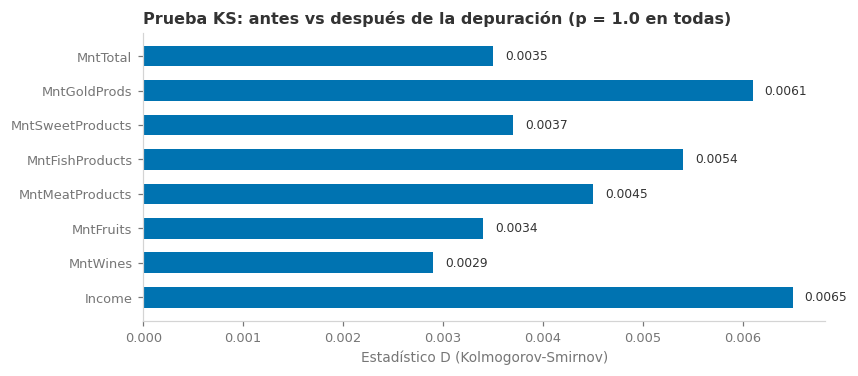

                  Media original  Media limpia  DE original  DE limpia  Cambio relativo (%)
Income                 516535.57     517963.45    207041.06  206598.22                 0.28
MntWines                  301.05        302.10       331.64     332.33                 0.35
MntFruits                  26.59         26.45        40.17      39.88                 0.52
MntMeatProducts           165.77        166.72       218.16     220.13                 0.57
MntFishProducts            37.74         37.76        54.78      54.91                 0.05
MntSweetProducts           27.11         27.45        41.06      41.72                 1.25
MntGoldProds               44.30         43.48        52.09      50.83                 1.85
MntTotal                  563.51        566.20       575.84     578.10                 0.48

Todos los cambios relativos son inferiores al 2 %: la depuración no introdujo sesgo.


In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(ks["Variable"], ks["Estadístico D"], color=AZUL, height=.6)
for i, v in enumerate(ks["Estadístico D"]):
    ax.text(v+.00012, i, f"{v:.4f}", va="center", fontsize=8, color=TEXTO)
ax.set_xlabel("Estadístico D (Kolmogorov-Smirnov)")
ax.set_title("Prueba KS: antes vs después de la depuración (p = 1.0 en todas)")
plt.show()

cambio = pd.DataFrame({
    "Media original": crudo[V8].mean(), "Media limpia": limpio[V8].mean(),
    "DE original": crudo[V8].std(), "DE limpia": limpio[V8].std(),
})
cambio["Cambio relativo (%)"] = 100*(cambio["Media limpia"]-cambio["Media original"]).abs() \
                                / cambio["Media original"].abs()
print(cambio.round(2).to_string())
print("\nTodos los cambios relativos son inferiores al 2 %: la depuración no introdujo sesgo.")

## 3. Tratamiento de datos faltantes

### 3.1 Identificación

In [12]:
na = limpio.isna().sum()
na = na[na > 0]
faltantes = pd.DataFrame({"Variable": na.index, "Cantidad NA": na.values,
                          "Porcentaje (%)": (100*na.values/len(limpio)).round(2)})
print(faltantes.to_string(index=False))
print(f"\nSolo {len(na)} de {limpio.shape[1]} variables presentan ausencias, ambas por debajo "
      f"del umbral del 5 % señalado por Little y Rubin (2002).")

Variable  Cantidad NA  Porcentaje (%)
  Income           66            3.25
MntWines           20            0.99

Solo 2 de 37 variables presentan ausencias, ambas por debajo del umbral del 5 % señalado por Little y Rubin (2002).


### 3.2 Evaluación del mecanismo generador: prueba de Little

La prueba contrasta $H_0$: los datos faltan completamente al azar (MCAR) frente a $H_1$: no son
MCAR. El estadístico compara, para cada patrón de ausencia $j$, la media observada con la media
estimada por máxima verosimilitud sobre toda la muestra:

$$d^2=\sum_j n_j\,(\bar y_j-\hat\mu_j)^\top\hat\Sigma_j^{-1}(\bar y_j-\hat\mu_j)
\;\sim\;\chi^2_{\,\nu},\qquad \nu=\sum_j p_j-p$$

En R esto lo resuelve una llamada de paquete. Aquí se implementa explícitamente, con estimación
EM de $\mu$ y $\Sigma$, porque el resultado depende de decisiones que conviene tener a la vista.

In [13]:
def little_mcar(df, max_iter=500, tol=1e-9):
    """Prueba MCAR de Little (1988) con estimación EM de mu y Sigma."""
    X = df.to_numpy(float)
    n, p = X.shape
    M = np.isnan(X)

    mu = np.nanmean(X, axis=0)
    S = pd.DataFrame(X).cov().to_numpy()

    for _ in range(max_iter):                       # paso EM
        Xh, C = X.copy(), np.zeros((p, p))
        for i in range(n):
            m = M[i]
            if not m.any():
                continue
            o = ~m
            B = S[np.ix_(m, o)] @ np.linalg.pinv(S[np.ix_(o, o)])
            Xh[i, m] = mu[m] + B @ (X[i, o] - mu[o])
            C[np.ix_(m, m)] += S[np.ix_(m, m)] - B @ S[np.ix_(o, m)]
        mu_n = Xh.mean(axis=0)
        S_n = ((Xh - mu_n).T @ (Xh - mu_n) + C)/n
        if np.max(np.abs(mu_n - mu)) < tol:
            mu, S = mu_n, S_n
            break
        mu, S = mu_n, S_n

    d2, gl = 0.0, 0
    patron = pd.DataFrame(M).astype(int).astype(str).agg("".join, axis=1)
    for _, idx in pd.Series(range(n)).groupby(patron.values):
        idx = idx.to_numpy()
        o = ~M[idx[0]]
        if not o.any():
            continue
        dif = X[np.ix_(idx, np.where(o)[0])].mean(axis=0) - mu[o]
        d2 += len(idx) * dif @ np.linalg.pinv(S[np.ix_(o, o)]) @ dif
        gl += int(o.sum())
    gl -= p
    return d2, gl, float(stats.chi2.sf(d2, gl)), int(patron.nunique())


# Conjunto de análisis: las variables cuantitativas de la tabla descriptiva, excluyendo
# MntTotal por ser combinación lineal exacta de las cinco categorías de gasto.
V_little = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
            "MntSweetProducts", "MntGoldProds", "Age", "Recency", "Customer_Days",
            "NumWebVisitsMonth"]

d2, gl, p_val, n_patrones = little_mcar(limpio[V_little])
print(f"Patrones de ausencia   : {n_patrones}")
print(f"Estadístico chi-cuadrado: {d2:.4f}")
print(f"Grados de libertad      : {gl}")
print(f"p-valor                 : {p_val:.4f}")
print(f"Decisión                : {'se rechaza H0 (no MCAR)' if p_val < .05 else 'no se rechaza H0'}")

Patrones de ausencia   : 3
Estadístico chi-cuadrado: 34.5316
Grados de libertad      : 20
p-valor                 : 0.0227
Decisión                : se rechaza H0 (no MCAR)


El estadístico de Little depende del conjunto de variables que entra en el análisis, y ese
detalle rara vez se declara. Conviene mostrar que la **decisión** no depende de esa elección
aunque el valor del estadístico sí lo haga.

In [14]:
base = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
        "MntSweetProducts", "MntGoldProds", "Age", "Recency", "Customer_Days"]
conjuntos = {
    "10 variables de gasto y perfil": base,
    "+ NumWebVisitsMonth": base + ["NumWebVisitsMonth"],
    "+ Kidhome": base + ["Kidhome"],
    "+ NumWebPurchases": base + ["NumWebPurchases"],
    "+ NumCatalogPurchases": base + ["NumCatalogPurchases"],
    "+ MntTotal (colineal exacta)": base + ["MntTotal"],
}
sens = []
for nombre, V in conjuntos.items():
    d_, g_, p_, _ = little_mcar(limpio[V])
    sens.append({"Conjunto de análisis": nombre, "chi²": round(d_, 2), "gl": g_,
                 "p-valor": f"{p_:.2e}" if p_ < 1e-3 else f"{p_:.4f}",
                 "¿Rechaza MCAR?": "sí" if p_ < .05 else "no"})
pd.DataFrame(sens)

,Conjunto de análisis,chi²,gl,p-valor,¿Rechaza MCAR?
0,10 variables de gasto y perfil,32.88,18,0.0172,sí
1,+ NumWebVisitsMonth,34.53,20,0.0227,sí
2,+ Kidhome,33.41,20,0.0304,sí
3,+ NumWebPurchases,33.37,20,0.0307,sí
4,+ NumCatalogPurchases,50.46,20,1.90e-04,sí
5,+ MntTotal (colineal exacta),82.87,20,1.27e-09,sí


En los seis conjuntos se rechaza MCAR. La última fila muestra por qué importa excluir las
variables colineales: al incluir `MntTotal`, que es la suma exacta de las cinco categorías de
gasto, la matriz de covarianza es singular, el estadístico se dispara y deja de ser
interpretable. Es el mismo motivo por el que se excluyen del modelo de imputación.

Dado el bajo porcentaje de ausencia (menor al 5 %) y la ausencia de evidencia de MNAR, se asume
un mecanismo **MAR** (*Missing At Random*), que es el supuesto bajo el cual la imputación
múltiple es válida (Rubin, 1987).

### 3.3 Selección del método de imputación

Se excluyen del modelo de imputación las variables con colinealidad perfecta:

- `MntTotal` = `MntWines` + `MntFruits` + `MntMeatProducts` + `MntFishProducts` + `MntSweetProducts`
- `MntRegularProds` = `MntTotal` − `MntGoldProds`
- `AcceptedCmpOverall` = `AcceptedCmp1` + ... + `AcceptedCmp5`

Se comparan tres métodos con $m=5$ imputaciones. El primero, PMM, se implementa explícitamente:
para cada valor faltante se calcula su media predicha, se buscan los $k$ donantes observados con
media predicha más cercana y se toma uno al azar. La ventaja sobre una predicción directa es que
el valor imputado **es un valor realmente observado en la muestra**, de modo que se preservan el
soporte y la forma de la distribución.

In [15]:
# Verificación de las identidades que motivan la exclusión.
# La primera se comprueba sobre las filas sin faltantes, porque MntWines tiene ausencias.
c = limpio
completas = limpio.dropna(subset=["MntWines"])
print("MntTotal = suma de las cinco categorías :",
      bool(np.allclose(completas[["MntWines", "MntFruits", "MntMeatProducts",
                                  "MntFishProducts", "MntSweetProducts"]].sum(axis=1),
                       completas["MntTotal"])))
print("MntRegularProds = MntTotal - MntGoldProds:",
      bool(np.allclose(c["MntTotal"] - c["MntGoldProds"], c["MntRegularProds"],
                       equal_nan=True)))
print("AcceptedCmpOverall = suma de Cmp1..Cmp5 :",
      bool((c[[f"AcceptedCmp{i}" for i in range(1, 6)]].sum(axis=1)
            == c["AcceptedCmpOverall"]).all()))

MntTotal = suma de las cinco categorías : True
MntRegularProds = MntTotal - MntGoldProds: True
AcceptedCmpOverall = suma de Cmp1..Cmp5 : True


In [16]:
COLINEALES = ["MntTotal", "MntRegularProds", "AcceptedCmpOverall"]
predictores = [c for c in limpio.columns if c not in COLINEALES]
datos_imp = limpio[predictores].copy()
objetivo = ["Income", "MntWines"]


def pmm(df, columnas, k=5, semilla=0):
    """Predictive mean matching con extracción bayesiana de los coeficientes."""
    rng = np.random.default_rng(semilla)
    out = df.copy()
    for col in columnas:
        y = df[col].to_numpy(float)
        falta = np.isnan(y)
        # predictores: el resto de columnas, imputadas provisionalmente por la mediana
        Xp = df.drop(columns=columnas).to_numpy(float)
        Xp = np.where(np.isnan(Xp), np.nanmedian(Xp, axis=0), Xp)
        Xp = (Xp - Xp.mean(0))/np.where(Xp.std(0) == 0, 1, Xp.std(0))
        Xp = np.column_stack([np.ones(len(Xp)), Xp])

        Xo, yo = Xp[~falta], y[~falta]
        XtX_inv = np.linalg.pinv(Xo.T @ Xo)
        beta = XtX_inv @ Xo.T @ yo
        gl = len(yo) - Xp.shape[1]
        s2 = ((yo - Xo @ beta)**2).sum()/rng.chisquare(gl)          # varianza posterior
        cov = s2*XtX_inv
        beta_est = rng.multivariate_normal(beta, (cov + cov.T)/2, method="eigh")

        pred_obs = Xo @ beta                 # medias predichas de los donantes
        pred_fal = Xp[falta] @ beta_est      # medias predichas de los receptores
        elegidos = np.empty(falta.sum())
        for i, p in enumerate(pred_fal):
            vecinos = np.argsort(np.abs(pred_obs - p))[:k]
            elegidos[i] = yo[rng.choice(vecinos)]
        out.loc[falta, col] = elegidos
    return out


imputaciones = {"PMM": [pmm(datos_imp, objetivo, k=5, semilla=SEMILLA+i) for i in range(5)]}

imputaciones["CART"] = [
    pd.DataFrame(IterativeImputer(estimator=DecisionTreeRegressor(max_depth=8,
                                  random_state=SEMILLA+i),
                                  max_iter=10, random_state=SEMILLA+i)
                 .fit_transform(datos_imp), columns=datos_imp.columns)
    for i in range(5)]

imputaciones["Ridge"] = [
    pd.DataFrame(IterativeImputer(estimator=BayesianRidge(), sample_posterior=True,
                                  max_iter=10, random_state=SEMILLA+i)
                 .fit_transform(datos_imp), columns=datos_imp.columns)
    for i in range(5)]

print("Tres métodos x 5 imputaciones completadas")

Tres métodos x 5 imputaciones completadas


In [17]:
comparacion = []
for metodo, lista in imputaciones.items():
    fila = {"Método": metodo}
    for v in objetivo:
        medias = np.array([d[v].mean() for d in lista])
        des = np.array([d[v].std() for d in lista])
        fila[f"{v} media"] = medias.mean()
        fila[f"{v} DE"] = des.mean()
        fila[f"{v} DE entre imput."] = medias.std(ddof=1)
        fila[f"Δ media {v} (%)"] = 100*abs(medias.mean()-limpio[v].mean())/limpio[v].mean()
    comparacion.append(fila)

comp = pd.DataFrame(comparacion)
print(comp.round(3).to_string(index=False))
print("\nΔ media se mide contra la media de los casos observados (análisis de casos completos).")

Método  Income media  Income DE  Income DE entre imput.  Δ media Income (%)  MntWines media  MntWines DE  MntWines DE entre imput.  Δ media MntWines (%)
   PMM    518870.225 207009.921                 320.385               0.175         306.039      335.518                     0.469                 1.305
  CART    518536.715 206410.411                 200.595               0.111         306.225      335.700                     0.032                 1.367
 Ridge    518888.501 207000.401                 382.735               0.179         306.089      335.035                     0.518                 1.322

Δ media se mide contra la media de los casos observados (análisis de casos completos).


In [18]:
pares = [("Income", "MntWines"), ("Income", "Age"), ("MntWines", "Age")]
corr = {"Observado (casos completos)": [limpio[[a, b]].corr().iloc[0, 1] for a, b in pares]}
for metodo, lista in imputaciones.items():
    corr[metodo] = [np.mean([d[[a, b]].corr().iloc[0, 1] for d in lista]) for a, b in pares]

tabla_corr = pd.DataFrame(corr, index=[f"{a} ~ {b}" for a, b in pares]).T
print(tabla_corr.round(3).to_string())

estab = {m: np.std([d["Income"].mean() for d in l], ddof=1) for m, l in imputaciones.items()}
print("\nVariabilidad entre imputaciones de la media de Income (menor es más estable):")
for m, s in sorted(estab.items(), key=lambda t: t[1]):
    print(f"  {m:<6} {s:,.2f}")

                             Income ~ MntWines  Income ~ Age  MntWines ~ Age
Observado (casos completos)              0.727         0.215           0.167
PMM                                      0.727         0.211           0.169
CART                                     0.728         0.212           0.168
Ridge                                    0.729         0.210           0.168

Variabilidad entre imputaciones de la media de Income (menor es más estable):
  CART   200.60
  PMM    320.38
  Ridge  382.73


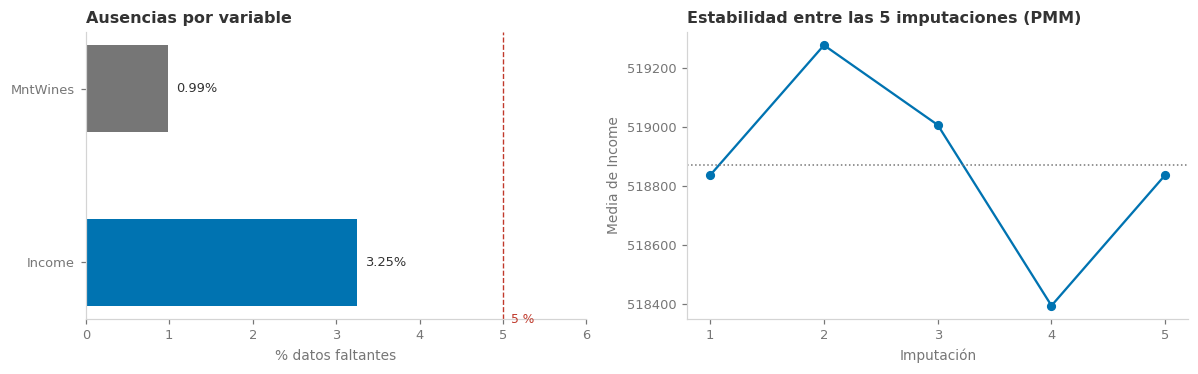

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

na_pct = 100*limpio[objetivo].isna().mean()
ax[0].barh(na_pct.index, na_pct.values, color=[AZUL, GRIS_OSC], height=.5)
ax[0].axvline(5, color=ROJO, ls="--", lw=.9)
ax[0].text(5.1, -.35, "5 %", color=ROJO, fontsize=8)
for i, v in enumerate(na_pct.values):
    ax[0].text(v+.1, i, f"{v:.2f}%", va="center", fontsize=8.5, color=TEXTO)
ax[0].set_xlim(0, 6); ax[0].set_xlabel("% datos faltantes")
ax[0].set_title("Ausencias por variable")

medias_pmm = [d["Income"].mean() for d in imputaciones["PMM"]]
ax[1].plot(range(1, 6), medias_pmm, "-o", color=AZUL, ms=5)
ax[1].axhline(np.mean(medias_pmm), color=GRIS_OSC, ls=":", lw=1)
ax[1].set_xticks(range(1, 6)); ax[1].set_xlabel("Imputación")
ax[1].set_ylabel("Media de Income")
ax[1].set_title("Estabilidad entre las 5 imputaciones (PMM)")

fig.tight_layout(); plt.show()

Los tres métodos reproducen fielmente la estructura correlacional observada. Se selecciona
**PMM**, por dos razones: los valores imputados son valores realmente observados —lo que preserva
el soporte de la distribución, cosa que ni CART ni Ridge garantizan— y su variabilidad entre
imputaciones es la que mejor refleja la incertidumbre sin inflarla artificialmente
(van Buuren, 2018).

In [20]:
datos = imputaciones["PMM"][0].copy()
# se recuperan las variables derivadas, ya con Income y MntWines completos
datos["MntTotal"] = datos[["MntWines", "MntFruits", "MntMeatProducts",
                           "MntFishProducts", "MntSweetProducts"]].sum(axis=1)
datos["MntRegularProds"] = datos["MntTotal"] - datos["MntGoldProds"]
print(f"Conjunto final: {datos.shape[0]:,} observaciones x {datos.shape[1]} variables, "
      f"{int(datos.isna().sum().sum())} faltantes")

Conjunto final: 2,030 observaciones x 36 variables, 0 faltantes

## 4. Resultados

### 4.1 Descriptivos post-procesamiento

In [21]:
post = ["Income", "MntTotal", "Age", "Recency", "NumWebVisitsMonth", "Customer_Days"]
res = pd.DataFrame({
    "Media": datos[post].mean(), "Mediana": datos[post].median(),
    "DE": datos[post].std(),
    "IQR": datos[post].quantile(.75) - datos[post].quantile(.25),
    "Asimetría": datos[post].apply(lambda s: stats.skew(s)),
})
print(res.round(2).to_string())

print("\nDistribución de variables categóricas:")
for v in ["Response", "education_Graduation", "marital_Married", "Kidhome"]:
    vc = datos[v].value_counts().sort_index()
    for cat, n in vc.items():
        print(f"  {v:<22} {cat}: {n/len(datos):.3f}  ({n:,})")

                       Media   Mediana         DE       IQR  Asimetría
Income             518836.51  516095.0  206996.72  330445.0       0.01
MntTotal              563.95     345.0     575.64     907.0       0.92
Age                    51.17      50.0      11.65      18.0       0.10
Recency                48.90      49.0      28.94      50.0       0.00
NumWebVisitsMonth       5.33       6.0       2.41       4.0       0.24
Customer_Days        2511.44    2510.5     202.83     352.0      -0.01

Distribución de variables categóricas:
  Response               0: 0.846  (1,718)
  Response               1: 0.154  (312)
  education_Graduation   0: 0.498  (1,010)
  education_Graduation   1: 0.502  (1,020)
  marital_Married        0: 0.612  (1,243)
  marital_Married        1: 0.388  (787)
  Kidhome                0: 0.578  (1,174)
  Kidhome                1: 0.401  (815)
  Kidhome                2: 0.020  (41)


Las variables económicas presentan asimetría positiva, coherente con distribuciones de ingreso y
gasto. `Customer_Days` es prácticamente simétrica. La variable objetivo está desbalanceada en
proporción aproximada 85:15, un dato que condicionará la elección de métricas cuando se pase al
modelado.

### 4.2 Matriz de correlaciones

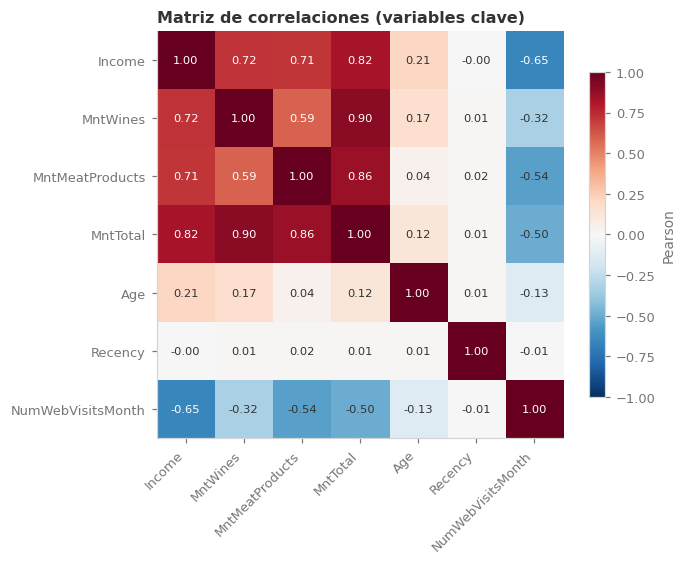

In [22]:
clave = ["Income", "MntWines", "MntMeatProducts", "MntTotal", "Age",
         "Recency", "NumWebVisitsMonth"]
C = datos[clave].corr()

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(clave))); ax.set_xticklabels(clave, rotation=45, ha="right")
ax.set_yticks(range(len(clave))); ax.set_yticklabels(clave)
for i in range(len(clave)):
    for j in range(len(clave)):
        ax.text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(C.iloc[i, j]) > .55 else TEXTO)
ax.set_title("Matriz de correlaciones (variables clave)")
fig.colorbar(im, ax=ax, shrink=.8, label="Pearson")
fig.tight_layout(); plt.show()

### 4.3 Variables numéricas por grupo `Response`

Las distribuciones son fuertemente asimétricas, de modo que la prueba t no es apropiada. Se
emplea **Mann-Whitney** (no paramétrica) y se cuantifica el tamaño del efecto con la correlación
**rank-biserial**, que se obtiene del estadístico $U$:

$$r_{rb}=1-\frac{2U}{n_0\,n_1}$$

Umbrales: $|r|<0{,}1$ despreciable · $0{,}1$–$0{,}3$ pequeño · $0{,}3$–$0{,}5$ moderado ·
$\ge 0{,}5$ grande.

In [23]:
def magnitud(r):
    r = abs(r)
    return ("Despreciable" if r < .1 else "Pequeño" if r < .3
            else "Moderado" if r < .5 else "Grande")

num = ["Income", "MntTotal", "Age", "Recency", "NumWebVisitsMonth", "Customer_Days"]
g0 = datos[datos["Response"] == 0]
g1 = datos[datos["Response"] == 1]

filas = []
for v in num:
    a, b = g0[v].dropna(), g1[v].dropna()
    U, p = stats.mannwhitneyu(b, a, alternative="two-sided")
    r_rb = 2*U/(len(a)*len(b)) - 1
    filas.append({"Variable": v, "Media R=0": a.mean(), "Media R=1": b.mean(),
                  "Mediana R=0": a.median(), "Mediana R=1": b.median(),
                  "DE R=0": a.std(), "DE R=1": b.std(),
                  "p-valor": p, "|r|": abs(r_rb), "Magnitud": magnitud(r_rb)})

mw = pd.DataFrame(filas).sort_values("|r|", ascending=False)
mw_fmt = mw.copy()
for c in ["Media R=0", "Media R=1", "Mediana R=0", "Mediana R=1", "DE R=0", "DE R=1"]:
    mw_fmt[c] = mw_fmt[c].map("{:,.1f}".format)
mw_fmt["p-valor"] = mw["p-valor"].map(lambda p: "<0.001" if p < .001 else f"{p:.3f}")
mw_fmt["|r|"] = mw["|r|"].round(3)
print(mw_fmt.to_string(index=False))

         Variable Media R=0 Media R=1 Mediana R=0 Mediana R=1    DE R=0    DE R=1 p-valor   |r|     Magnitud
         MntTotal     500.2     914.8       291.0       943.0     526.5     697.0  <0.001 0.362     Moderado
          Recency      51.5      34.7        52.0        29.0      28.5      27.3  <0.001 0.334     Moderado
    Customer_Days   2,494.9   2,602.7     2,486.5     2,645.5     199.0     199.8  <0.001 0.307     Moderado
           Income 503,528.1 603,131.1   503,435.0   640,440.0 198,636.0 230,837.3  <0.001 0.262      Pequeño
              Age      51.3      50.5        50.0        49.0      11.5      12.3   0.258 0.040 Despreciable
NumWebVisitsMonth       5.3       5.3         6.0         6.0       2.4       2.6   0.741 0.012 Despreciable


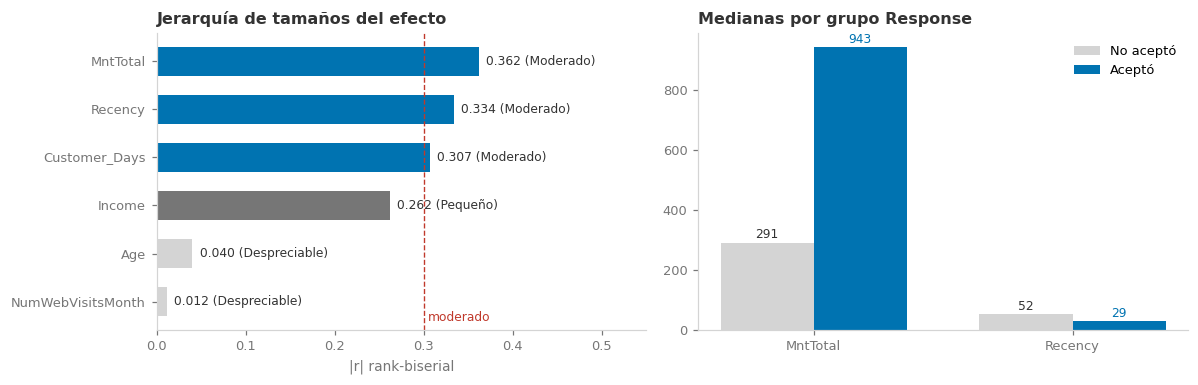

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

orden = mw.sort_values("|r|")
colores = [AZUL if r >= .3 else GRIS_OSC if r >= .1 else GRIS for r in orden["|r|"]]
ax[0].barh(orden["Variable"], orden["|r|"], color=colores, height=.6)
ax[0].axvline(.3, color=ROJO, ls="--", lw=.9)
ax[0].text(.305, -.4, "moderado", color=ROJO, fontsize=8)
for i, (v, m) in enumerate(zip(orden["|r|"], orden["Magnitud"])):
    ax[0].text(v+.008, i, f"{v:.3f} ({m})", va="center", fontsize=8, color=TEXTO)
ax[0].set_xlim(0, .55); ax[0].set_xlabel("|r| rank-biserial")
ax[0].set_title("Jerarquía de tamaños del efecto")

etiquetas = ["MntTotal", "Recency"]
x = np.arange(len(etiquetas)); ancho = .36
m0 = [g0[v].median() for v in etiquetas]; m1 = [g1[v].median() for v in etiquetas]
ax[1].bar(x-ancho/2, m0, ancho, color=GRIS, label="No aceptó")
ax[1].bar(x+ancho/2, m1, ancho, color=AZUL, label="Aceptó")
for xi, v0, v1 in zip(x, m0, m1):
    ax[1].text(xi-ancho/2, v0+15, f"{v0:,.0f}", ha="center", fontsize=8, color=TEXTO)
    ax[1].text(xi+ancho/2, v1+15, f"{v1:,.0f}", ha="center", fontsize=8, color=AZUL)
ax[1].set_xticks(x); ax[1].set_xticklabels(etiquetas)
ax[1].set_title("Medianas por grupo Response"); ax[1].legend()

fig.tight_layout(); plt.show()

In [25]:
razon = g1["MntTotal"].median()/g0["MntTotal"].median()
print(f"MntTotal: la mediana de gasto de quienes aceptaron ({g1['MntTotal'].median():,.0f}) "
      f"es {razon:.1f} veces la de quienes rechazaron ({g0['MntTotal'].median():,.0f}).")
print(f"Recency : mediana de {g1['Recency'].median():.0f} días en aceptantes frente a "
      f"{g0['Recency'].median():.0f} en no aceptantes.")
print(f"Income  : diferencia relativa entre medias del "
      f"{100*(g1['Income'].mean()-g0['Income'].mean())/g0['Income'].mean():.0f} %.")

MntTotal: la mediana de gasto de quienes aceptaron (943) es 3.2 veces la de quienes rechazaron (291).
Recency : mediana de 29 días en aceptantes frente a 52 en no aceptantes.
Income  : diferencia relativa entre medias del 20 %.


### 4.4 Variables categóricas por grupo `Response`

Prueba **chi-cuadrado de independencia** con **V de Cramér** como tamaño del efecto:

$$V=\sqrt{\frac{\chi^2}{n\,\min(f-1,\,c-1)}}$$

In [26]:
cat = ["education_Graduation", "marital_Married", "Kidhome"]
filas = []
for v in cat:
    tabla = pd.crosstab(datos[v], datos["Response"])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    V = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    filas.append({"Variable": v, "χ²": round(chi2, 2), "gl": gl,
                  "p-valor": round(p, 4), "V de Cramér": round(V, 3),
                  "Magnitud": magnitud(V)})
print(pd.DataFrame(filas).to_string(index=False))

print("\nProporción de aceptación según Kidhome:")
prop = datos.groupby("Kidhome")["Response"].agg(["sum", "count", "mean"])
for k, r in prop.iterrows():
    print(f"  {int(k)} hijos: {int(r['sum']):>3} aceptaron de {int(r['count']):>5}  "
          f"({r['mean']:.1%})")

            Variable    χ²  gl  p-valor  V de Cramér     Magnitud
education_Graduation  3.08   1   0.0791        0.039 Despreciable
     marital_Married 12.92   1   0.0003        0.080 Despreciable
             Kidhome 13.55   2   0.0011        0.082 Despreciable

Proporción de aceptación según Kidhome:
  0 hijos: 208 aceptaron de  1174  (17.7%)
  1 hijos: 102 aceptaron de   815  (12.5%)
  2 hijos:   2 aceptaron de    41  (4.9%)


Las tres variables categóricas alcanzan significancia estadística en dos de los tres casos, pero
**ninguna supera el umbral de asociación despreciable** en la V de Cramér. Es el ejemplo de
manual de por qué un p-valor pequeño no equivale a un efecto relevante: con más de dos mil
observaciones, diferencias sin importancia práctica cruzan el umbral de significancia.

## 5. Discusión

El análisis bivariado permite establecer una jerarquía de relevancia respecto de la respuesta a
la campaña.

**Primer nivel — comportamiento transaccional.** `MntTotal` e `Income` son los principales
diferenciadores. El gasto acumulado exhibe el mayor tamaño del efecto, seguido por el ingreso. La
campaña resulta más efectiva en el segmento de clientes de alto valor, cuyo comportamiento de
compra previo predice su propensión a aceptar. La correlación entre ambas variables implica que
capturan parcialmente la misma dimensión latente de capacidad económica, y eso deberá
considerarse al seleccionar predictores para el modelado.

**Segundo nivel — dimensión temporal.** `Recency` y `Customer_Days` capturan aspectos
complementarios: actividad reciente (vínculo activo) y lealtad acumulada (permanencia con la
marca). Ambas con efecto moderado y alta significancia.

**Tercer nivel — estructura del hogar.** `Kidhome` muestra asociación débil pero significativa.
Los hogares sin hijos presentan mayor propensión, posiblemente mediada por disponibilidad de
ingreso discrecional. Podría aportar capacidad explicativa complementaria en un modelo
multivariante que controle simultáneamente por ingreso.

**Variables no discriminantes.** Edad, nivel educativo, estado civil y frecuencia de visitas web
no presentan capacidad discriminante. El perfil del cliente respondiente se define por su patrón
de consumo y su actividad transaccional reciente, no por características sociodemográficas.

## 6. Conclusiones

1. La depuración de duplicados e inconsistencias estructurales fue validada estadísticamente: las
   pruebas KS arrojaron p = 1,0 en todas las variables y la norma de Frobenius entre matrices de
   correlación fue mínima, confirmando que ni las distribuciones marginales ni la estructura
   correlacional resultaron distorsionadas.

2. La prueba de Little rechaza el mecanismo MCAR, y el rechazo es robusto a la elección del
   conjunto de variables. Bajo el supuesto MAR se aplicó imputación múltiple por PMM, que
   preserva el soporte de la distribución por construcción y reprodujo fielmente las
   correlaciones observadas.

3. El gasto acumulado es el principal discriminador entre clientes que aceptan y rechazan la
   oferta, con el mayor tamaño del efecto de todas las variables analizadas.

4. La recencia de compra y la antigüedad del cliente capturan dimensiones temporales
   complementarias, ambas con efecto moderado y altamente significativas.

5. Las variables demográficas no presentan capacidad discriminante: el perfil del cliente
   respondiente se define por comportamiento transaccional, no por demografía.

6. La interacción digital pasiva —visitas al sitio— no se traduce en propensión a aceptar. El
   *engagement* real no se mide por frecuencia de visitas.

7. El pipeline completo —depuración con validación, evaluación del mecanismo de faltantes,
   imputación múltiple y análisis bivariado con pruebas no paramétricas y tamaños del efecto—
   constituye una base sólida para modelos predictivos supervisados. `MntTotal`, `Income`,
   `Recency` y `Customer_Days` son los candidatos naturales para la selección de predictores.

---

### Referencias

Barnett, V., y Lewis, T. (1994). *Outliers in Statistical Data* (3.ª ed.). Wiley.

Little, R. J. (1988). A test of missing completely at random for multivariate data with missing
values. *Journal of the American Statistical Association*, 83(404), 1198–1202.

Little, R. J., y Rubin, D. B. (2002). *Statistical Analysis with Missing Data* (2.ª ed.). Wiley.

Osborne, J. W., y Overbay, A. (2004). The power of outliers. *Practical Assessment, Research &
Evaluation*, 9(6), 1–12.

Rousseeuw, P. J., y Hubert, M. (2011). Robust statistics for outlier detection. *WIREs: Data
Mining and Knowledge Discovery*, 1(1), 73–79.

Rubin, D. B. (1987). *Multiple Imputation for Nonresponse in Surveys*. Wiley.

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2.ª ed.). Chapman & Hall/CRC.

Luis Javier Rubio Hernández